In [16]:
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GlobalAveragePooling1D, Activation, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

You can estimate how fast a network prediction can be calculated by calculating the number of floating point operations performed in the network. This function is a handy tool to do it. Use it like this `print(get_flops(my_model))` where `my_model` is your KERAS neural network model.

In [2]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
import tensorflow as tf
######################################Calculate FLOPS##########################################
def get_flops(model):
    '''
    Calculate FLOPS
    Parameters
    ----------
    model : tf.keras.Model
        Model for calculating FLOPS.

    Returns
    -------
    flops.total_float_ops : int
        Calculated FLOPS for the model
    '''

    batch_size = 1

    real_model = tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] + model.inputs[0].shape[1:], model.inputs[0].dtype))
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=frozen_func.graph,run_meta=run_meta, cmd='op', options=opts)
    return flops.total_float_ops

Downloading the data (1 signal data file and 5 noise data files)

In [3]:
# download data file that contains signal events
if not os.path.exists("trimmed100_data_signal_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq


In [4]:
# download data file that contains noise events
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0001.npy"):
  !gdown https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0002.npy"):
  !gdown https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0003.npy"):
  !gdown https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0004.npy"):
  !gdown https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0005.npy"):
  !gdown https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx

Load the data into memory and combine it into one array.

In [5]:
# load signal and noise data set into memory
noise = np.load("trimmed100_data_noise_3.6SNR_1ch_0000.npy")
for i in range(1,5):
  noise = np.vstack((noise,np.load(f"trimmed100_data_noise_3.6SNR_1ch_000{i}.npy")))
signal = np.load("trimmed100_data_signal_3.6SNR_1ch_0000.npy")
n_classes = 2

In [6]:
# combine noise and signal data set
x = np.vstack((noise, signal))
print(x.shape)
# in case you want to train a CNN, you need to add an empty dimension to the array
# which you can do via x = np.expand_dims(x, axis=-1)

# define labels. As we have only two categories, we don't use one-hot encoding
# but can just use "0" for noise and "1" for signal.
y = np.ones(len(x))
y[:len(noise)] = 0

(599997, 100)


Currently, the training data first contains all noise events and then only signal events. This is not optimal, especially because Keras will pick the last X% of the data set for the validation data (which would mean we train only on noise and then validate with signal, which does not make much sense). Therefore, we randomly shuffle the dataset. Important: The x and y arrays need to be shuffled identicially as in the code below.

In [7]:
# shuffel the data
shuffle = np.arange(x.shape[0], dtype=int)
np.random.shuffle(shuffle)
x = x[shuffle]
y = y[shuffle]

# to still be able to identify the signal events you can do
smask = y == 1
# then you can get all signal events via `x[smask]`
# and all noise events via `x[~smask]`


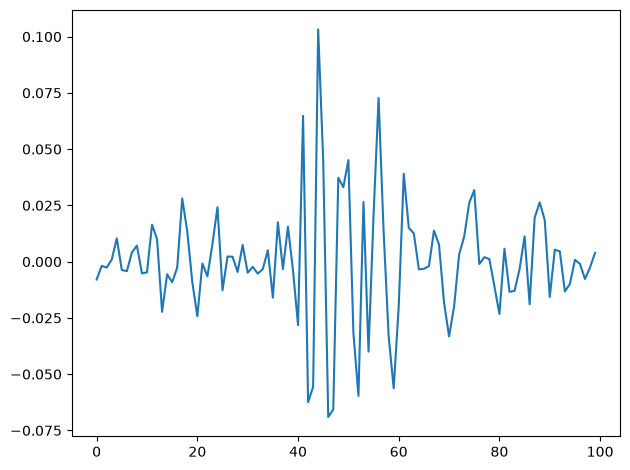

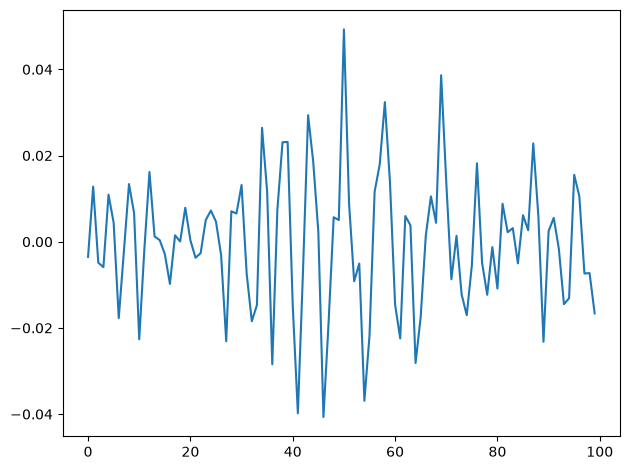

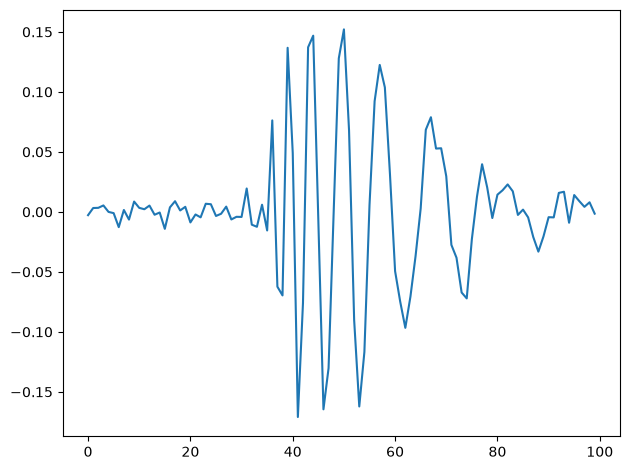

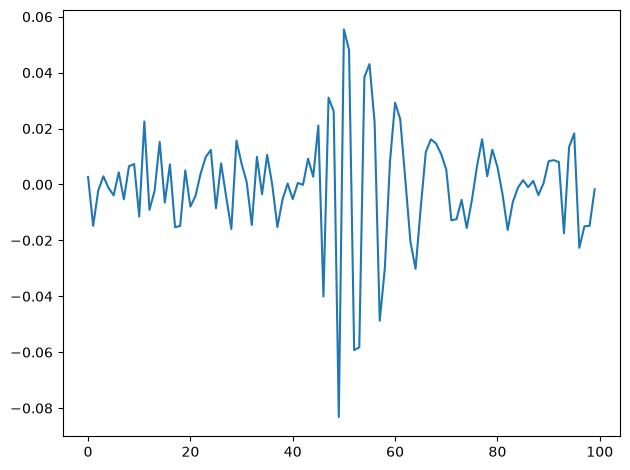

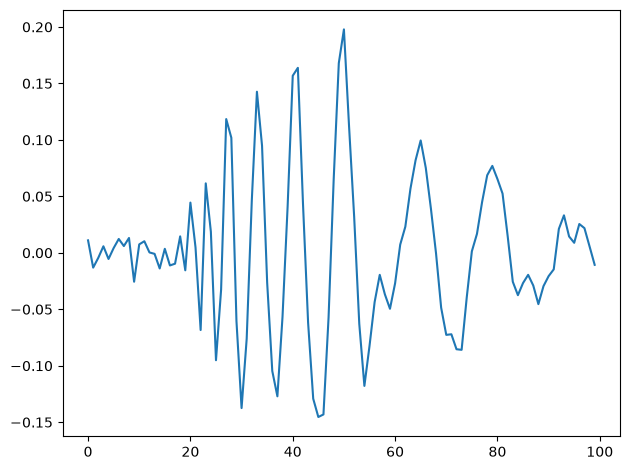

In [8]:
# plot a few signal events
for trace in x[smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

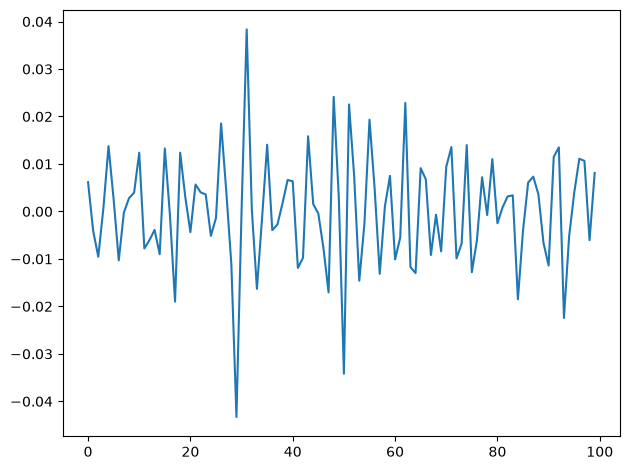

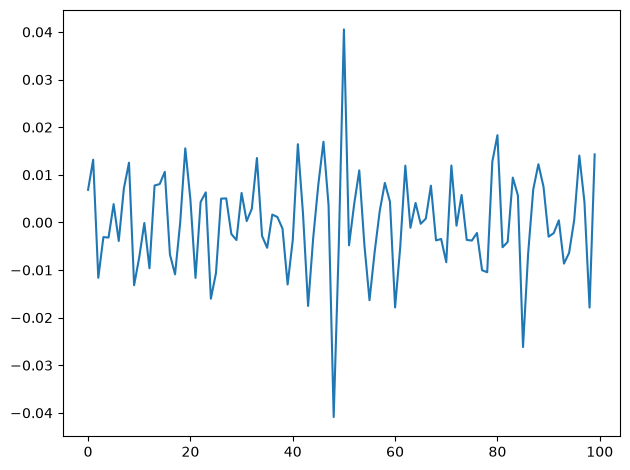

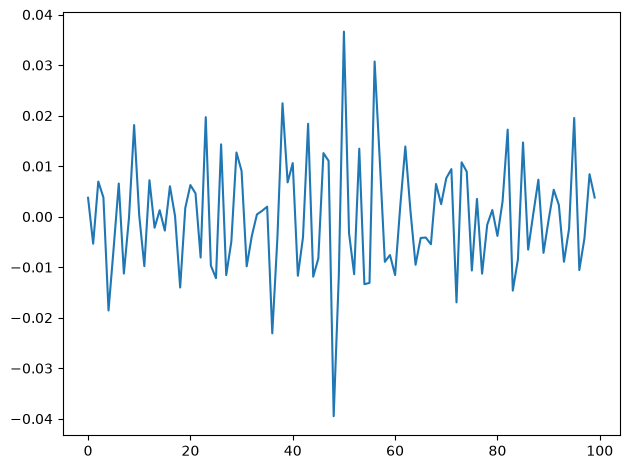

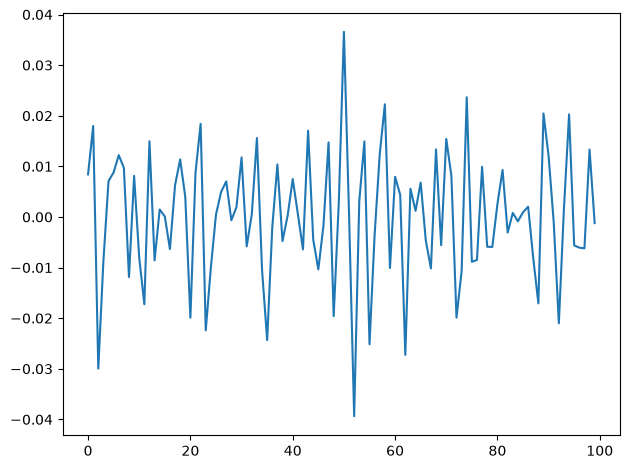

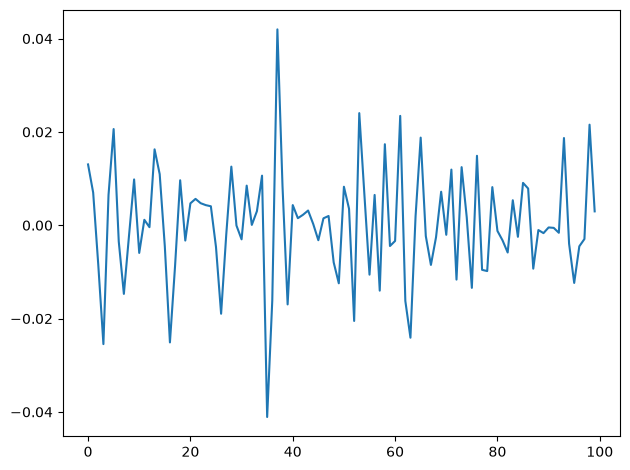

In [9]:
for trace in x[~smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

The signal data seems to have regions with high intensity, while the noise plots have high amplitudes aver the full x-axis. But that also might just be because of the random five picks for each category. In the end I wouldn't trust myself to differentiate between signal and noise.

In [10]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [11]:
model = Sequential(
    [
        keras.layers.Input(shape=x_scaled.shape[1:]),
        Dense(64, activation="swish"),
        Dense(32, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="simple_dense"
)
print(model.summary())

Model: "simple_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6464      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 8577 (33.50 KB)
Trainable params: 8577 (33.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


2026-07-05 19:14:59.646391: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-07-05 19:14:59.646408: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-05 19:14:59.646412: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-07-05 19:14:59.646432: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-05 19:14:59.646443: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
csv_logger = keras.callbacks.CSVLogger('training_history.csv', append=False)


In [13]:
model.compile(
    optimizer=keras.optimizers.legacy.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

model.fit(x_scaled, y, 
          batch_size=32, 
          epochs=20, 
          validation_split=0.2,
          callbacks=[csv_logger, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

model.save("simple_dense.h5")

Epoch 1/20


2026-07-05 19:15:00.079689: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


15000/15000 [==============================] - 66s 4ms/step - loss: 0.0404 - accuracy: 0.9882 - val_loss: 0.0214 - val_accuracy: 0.9942
Epoch 2/20
15000/15000 [==============================] - 64s 4ms/step - loss: 0.0187 - accuracy: 0.9951 - val_loss: 0.0187 - val_accuracy: 0.9951
Epoch 3/20
15000/15000 [==============================] - 64s 4ms/step - loss: 0.0157 - accuracy: 0.9959 - val_loss: 0.0173 - val_accuracy: 0.9953
Epoch 4/20
15000/15000 [==============================] - 66s 4ms/step - loss: 0.0139 - accuracy: 0.9963 - val_loss: 0.0163 - val_accuracy: 0.9956
Epoch 5/20
15000/15000 [==============================] - 66s 4ms/step - loss: 0.0125 - accuracy: 0.9968 - val_loss: 0.0153 - val_accuracy: 0.9961
Epoch 6/20
15000/15000 [==============================] - 66s 4ms/step - loss: 0.0113 - accuracy: 0.9971 - val_loss: 0.0160 - val_accuracy: 0.9960
Epoch 7/20
15000/15000 [==============================] - 66s 4ms/step - loss: 0.0106 - accuracy: 0.9972 - val_loss: 0.0158 - val

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


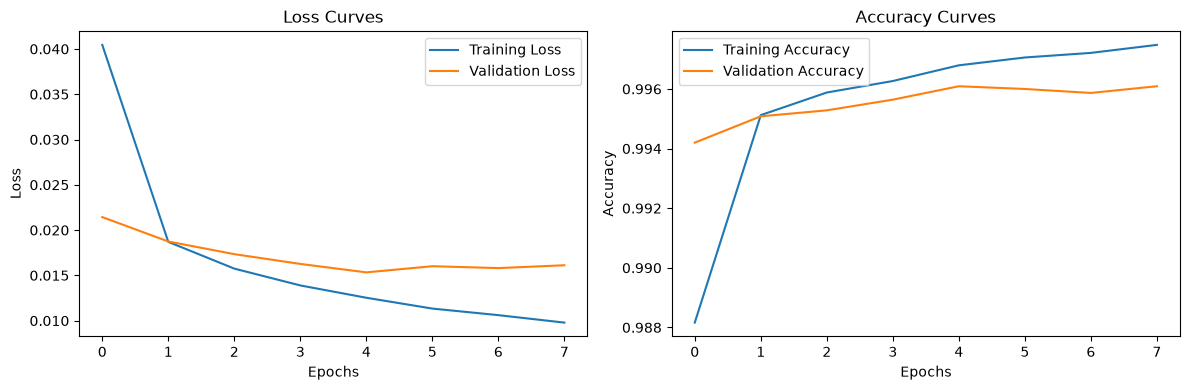

In [15]:
# plot loss and accuracy curves
df = pd.read_csv("training_history.csv")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df['loss'], label='Training Loss')
plt.plot(df['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(df['accuracy'], label='Training Accuracy')
plt.plot(df['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

18750/18750 [==============================] - 17s 884us/step


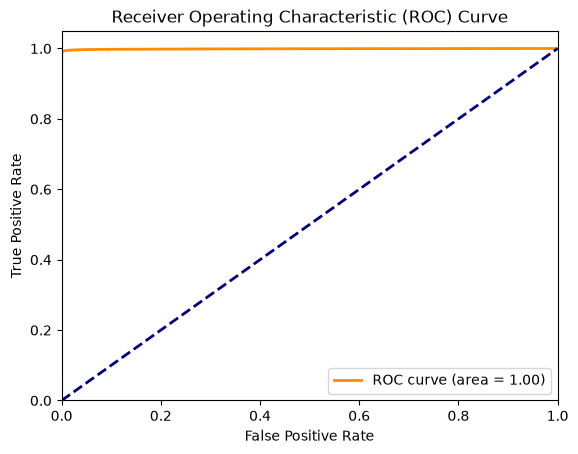

In [17]:
# plot ROC curve
y_pred = model.predict(x_scaled).ravel()
y_true = y

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

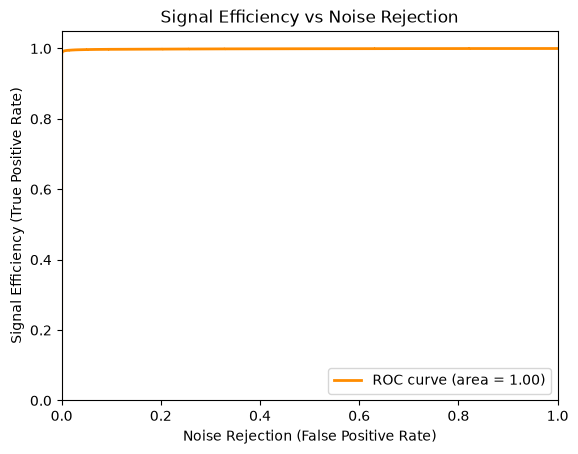

In [18]:
# plot signal efficiency vs noise rejection
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Noise Rejection (False Positive Rate)')
plt.ylabel('Signal Efficiency (True Positive Rate)')
plt.title('Signal Efficiency vs Noise Rejection')
plt.legend(loc="lower right")